# 03 · Train ResNet-50

Full fine-tuning of **ResNet-50** (ImageNet-V2 pretrained) for 16-class classification.

**Checklist:**
- [ ] Notebook 02 complete — `/content/data` has train/val/test  OR  Drive split exists
- [ ] Runtime → Runtime type → **A100 GPU**

In [1]:
# ── Cell 1: Setup ─────────────────────────────────────────────────────
import os, sys

GITHUB_USER = 'musarashid49'
REPO_NAME   = 'Image-Classification-with-CNN'
REPO_DIR    = f'/content/{REPO_NAME}'

if not os.path.isdir(REPO_DIR):
    !git clone https://github.com/{GITHUB_USER}/{REPO_NAME}.git {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)

from google.colab import drive
drive.mount('/content/drive')

import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else '⚠ NOT FOUND')
print('CUDA:', torch.version.cuda)

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 3.57 KiB | 3.57 MiB/s, done.
From https://github.com/musarashid49/Image-Classification-with-CNN
   5d8ad9d..9f9b394  master     -> origin/master
Updating 5d8ad9d..9f9b394
Fast-forward
 notebooks/03_train_resnet50.ipynb | 340 +++++++++++++++++++++++++++++++++++---
 1 file changed, 319 insertions(+), 21 deletions(-)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: NVIDIA A100-SXM4-40GB
CUDA: 12.8


In [2]:
# ── Cell 2: Paths ─────────────────────────────────────────────────────
LOCAL_DATA_DIR   = '/content/data'
DRIVE_SPLIT_PATH = '/content/drive/MyDrive/dataset_resplit'  # ← changed
DRIVE_RESULTS    = '/content/drive/MyDrive/pk_politicians_results'

In [3]:
import shutil, os, time

DRIVE_SPLIT_PATH = '/content/drive/MyDrive/dataset_resplit'
LOCAL_DATA_DIR = '/content/data'

if not os.path.isdir(LOCAL_DATA_DIR) or len(os.listdir(LOCAL_DATA_DIR)) == 0:
    print("Copying dataset from Drive → SSD...")
    t0 = time.time()
    shutil.rmtree(LOCAL_DATA_DIR, ignore_errors=True)
    shutil.copytree(DRIVE_SPLIT_PATH, LOCAL_DATA_DIR)
    print(f"✓ Done in {time.time()-t0:.1f}s")
else:
    print("✓ Data already on SSD — skipping copy")

from src.dataset import get_dataloaders
loaders = get_dataloaders(
    train_dir = os.path.join(LOCAL_DATA_DIR, 'train'),
    val_dir   = os.path.join(LOCAL_DATA_DIR, 'val'),
    test_dir  = os.path.join(LOCAL_DATA_DIR, 'test'),
)

✓ Data already on SSD — skipping copy

── DataLoader Summary ──────────────────────────────────────
  train     1064 images  |    33 batches  |  classes: 16
  val        205 images  |     7 batches  |  classes: 16
  test       159 images  |     5 batches  |  classes: 16

  Class-to-index mapping:
    [ 0]  ahmed_sharif_chaudhry
    [ 1]  altaf_hussain
    [ 2]  asfandyar_wali
    [ 3]  asif_ali_zardari
    [ 4]  bilawal_bhutto
    [ 5]  chaudhry_nisar
    [ 6]  fazlur_rehman
    [ 7]  imran_khan
    [ 8]  maryam_nawaz
    [ 9]  nawaz_sharif
    [10]  pervez_khattak
    [11]  pervez_musharraf
    [12]  rana_sanaullah
    [13]  shah_mehmood_qureshi
    [14]  shehbaz_sharif
    [15]  sirajul_haq


In [4]:
# ── Cell 4: Build ResNet-50 ────────────────────────────────────────────
from src.models import build_model

model = build_model(
    model_name  = 'resnet50',
    num_classes = 16,
    dropout     = 0.4,
    freeze_base = False,   # full fine-tuning
)

  [resnet50]  trainable params: 23,540,816 / 23,540,816


In [5]:
# ── Cell 5: Train ─────────────────────────────────────────────────────
from src.train import Trainer

trainer = Trainer(
    model      = model,
    loaders    = loaders,
    model_name = 'resnet50',
    config_overrides = {
        'num_epochs':    30,
        'learning_rate': 1e-4,
        'weight_decay':  1e-4,
    }
)
history = trainer.run()

Training on: cuda


  train:   0%|          | 0/33 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  train:  88%|████████▊ | 29/33 [00:05<00:00,  8.70it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [  1/30]  train_loss=2.6285  train_acc=0.2282  val_loss=2.3028  val_acc=0.4146  (6.8s)
  ✓ Checkpoint saved  (val_acc=0.4146)


  train:  36%|███▋      | 12/33 [00:01<00:02,  8.63it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  train:  64%|██████▎   | 21/33 [00:03<00:01,  7.51it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [  2/30]  train_loss=1.8703  train_acc=0.5758  val_loss=1.2795  val_acc=0.6829  (5.5s)
  ✓ Checkpoint saved  (val_acc=0.6829)


...

Epoch [ 19/30]  train_loss=0.0174  train_acc=0.9962  val_loss=0.4077  val_acc=0.8976  (5.9s)


  train:  18%|█▊        | 6/33 [00:01<00:05,  4.77it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  train:  73%|███████▎  | 24/33 [00:03<00:01,  6.87it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [ 20/30]  train_loss=0.0199  train_acc=0.9953  val_loss=0.4203  val_acc=0.8878  (5.8s)


  train:  27%|██▋       | 9/33 [00:01<00:03,  6.45it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  train:  33%|███▎      | 11/33 [00:01<00:03,  6.19it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  train:  67%|██████▋   | 22/33 [00:03<00:01,  6.59it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
                                                    

Epoch [ 21/30]  train_loss=0.0094  train_acc=0.9991  val_loss=0.3823  val_acc=0.9073  (6.0s)
  Early stopping triggered at epoch 21.

Training complete. Best val_acc = 0.9317
History saved → results/metrics/resnet50_history.json


  Training curves saved → results/plots/resnet50_training_curves.png


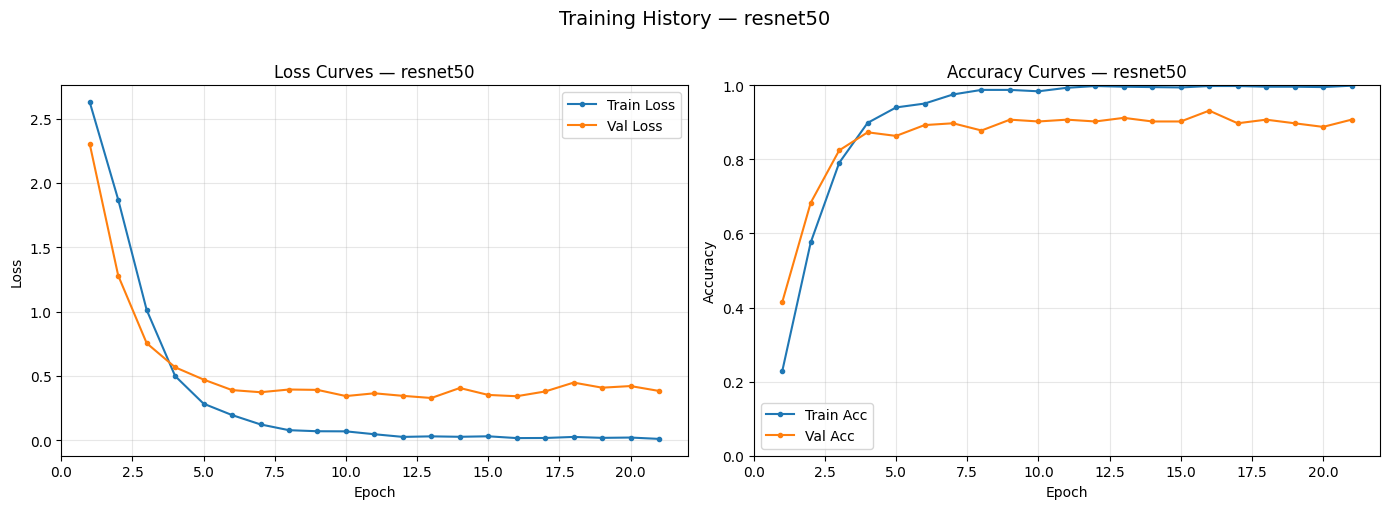

In [6]:
# ── Cell 6: Training curves ────────────────────────────────────────────
from src.evaluate import plot_training_curves
plot_training_curves(history, model_name='resnet50').show()


── Classification Report [resnet50] ──────────────────
                       precision    recall  f1-score   support

ahmed_sharif_chaudhry       1.00      1.00      1.00         8
        altaf_hussain       0.92      1.00      0.96        11
       asfandyar_wali       1.00      0.64      0.78        11
     asif_ali_zardari       0.88      0.88      0.88         8
       bilawal_bhutto       1.00      0.88      0.93         8
       chaudhry_nisar       0.73      0.73      0.73        11
        fazlur_rehman       0.92      0.92      0.92        13
           imran_khan       0.83      1.00      0.91        10
         maryam_nawaz       0.67      0.86      0.75        14
         nawaz_sharif       0.89      1.00      0.94         8
       pervez_khattak       0.78      0.88      0.82         8
     pervez_musharraf       1.00      0.83      0.91        12
       rana_sanaullah       0.90      1.00      0.95         9
 shah_mehmood_qureshi       0.86      0.60      0.71        1

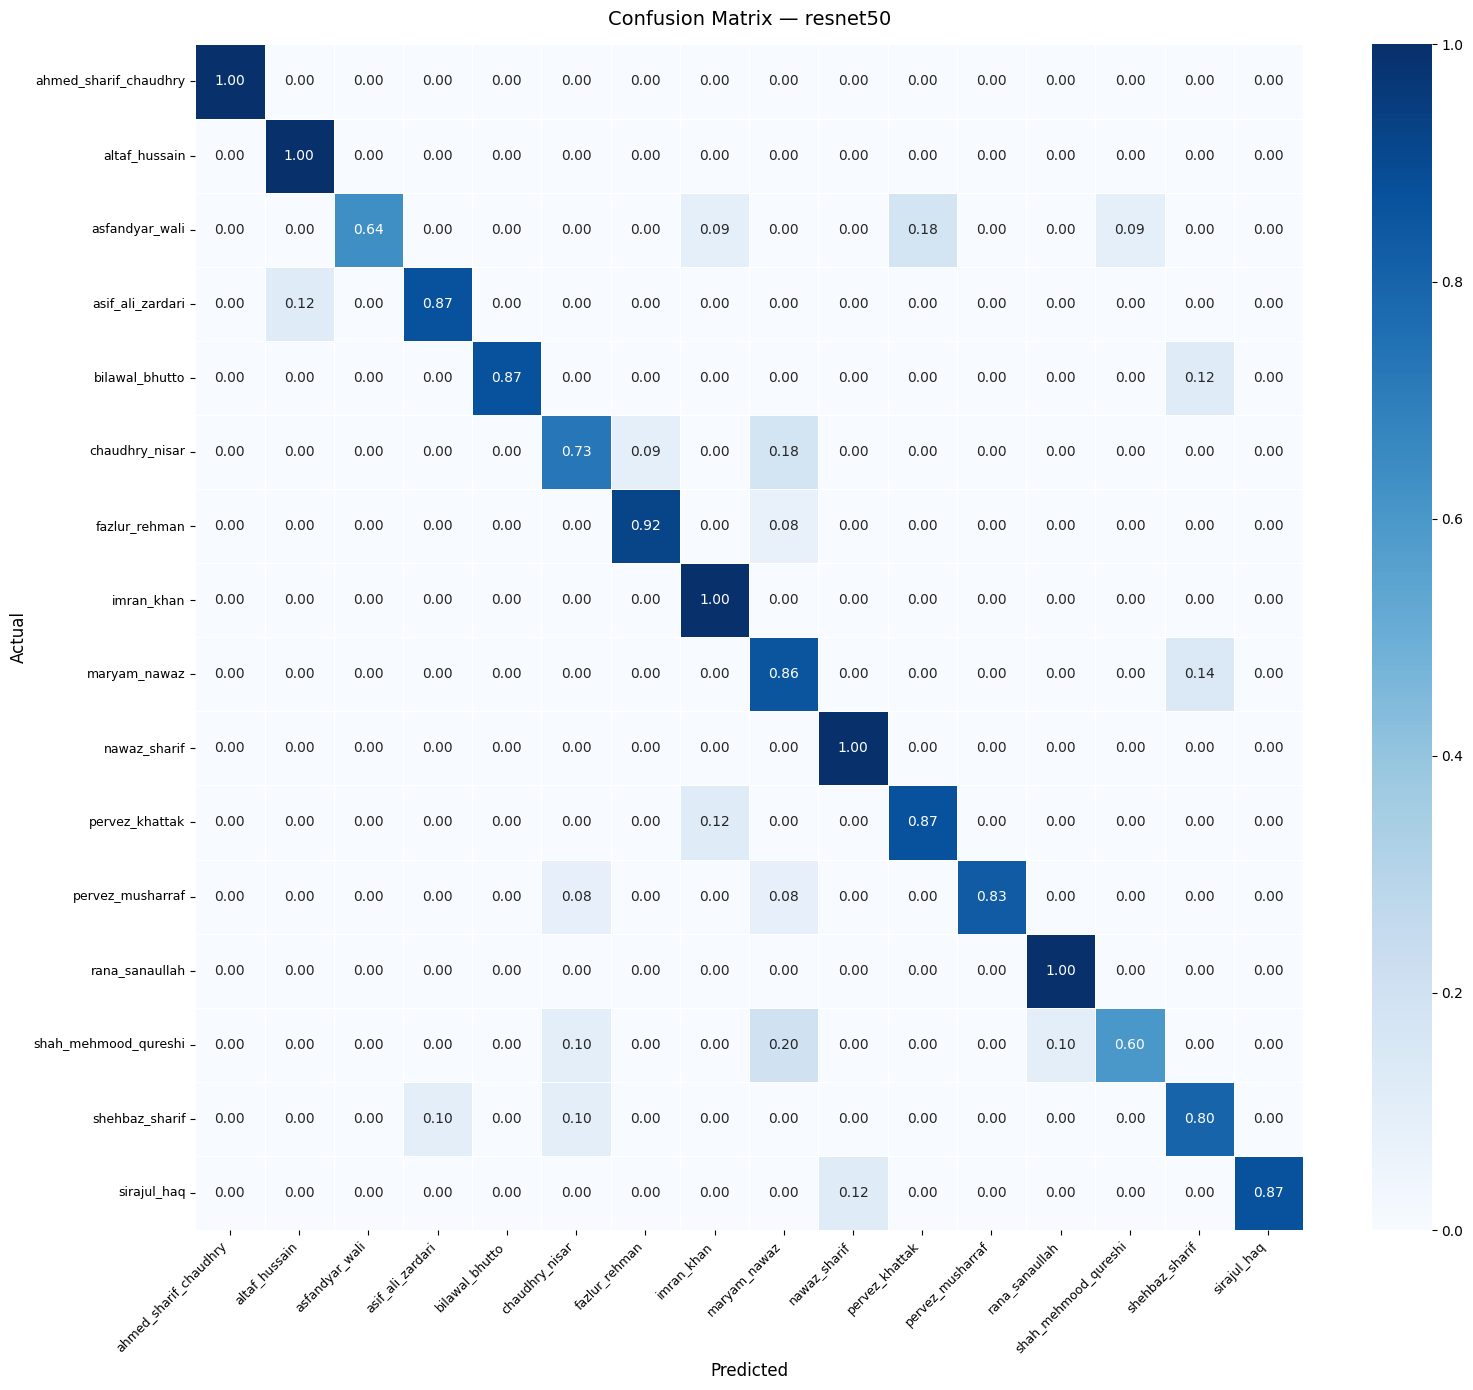

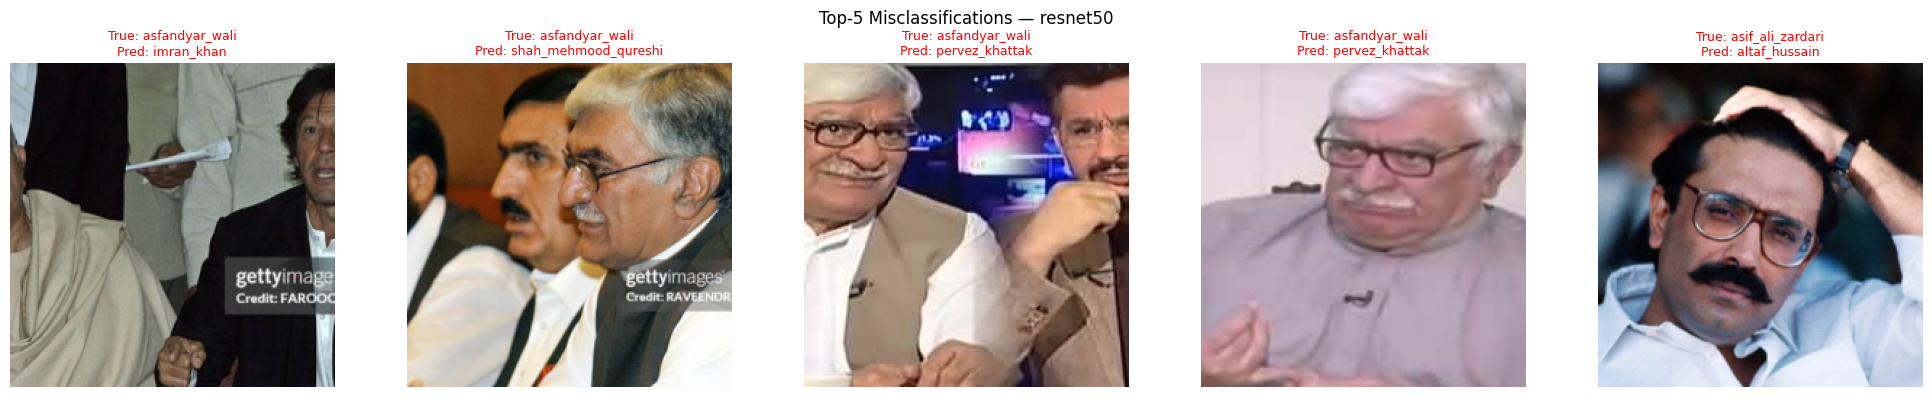

In [7]:
# ── Cell 7: Test set evaluation ───────────────────────────────────────
import torch
from src.evaluate import evaluate_model, plot_confusion_matrix, plot_misclassified

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
results = evaluate_model(model, loaders['test'], device, model_name='resnet50')

plot_confusion_matrix(results['y_true'], results['y_pred'], model_name='resnet50').show()
fig = plot_misclassified(results['images'], results['y_true'], results['y_pred'], model_name='resnet50')
if fig: fig.show()

In [8]:
# ── Cell 8: Log experiment ────────────────────────────────────────────
from src.utils import ExperimentLogger
logger = ExperimentLogger()
logger.log(
    model_name    = 'resnet50',
    test_accuracy = round(results['accuracy'], 4),
    macro_f1      = round(results['report']['macro avg']['f1-score'], 4),
    epochs_run    = len(history['train_loss']),
    lr=1e-4, batch_size=32,
    notes = 'Full fine-tuning, dropout=0.4, early stop patience=8',
)

  Experiment logged → experiments/experiment_log.json
    model_name: resnet50
    test_accuracy: 0.8616
    macro_f1: 0.8671
    epochs_run: 21
    lr: 0.0001
    batch_size: 32
    notes: Full fine-tuning, dropout=0.4, early stop patience=8
    timestamp: 2026-05-13 18:44:03


In [9]:
# ── Cell 9: Save results to Drive ─────────────────────────────────────
from src.utils import save_results_to_drive
save_results_to_drive('results', DRIVE_RESULTS)
print('✓ Saved. Next → 04_train_efficientnet.ipynb')

  Saving results to Drive …
  Results saved → /content/drive/MyDrive/pk_politicians_results
✓ Saved. Next → 04_train_efficientnet.ipynb
